# Customer Grievance NLP Analysis
  
**Objective:** As a data scientist at a major bank, classify complaints by department, analyze sentiment, and derive actionable insights

**Steps:**
1. Data loading & type checks  
2. Date‐range exploration  
3. Text preprocessing  
4. TF–IDF + classical classifier  
5. Transformer‐based classifier (zero-shot demo)  
6. VADER sentiment scoring & trend plot


In [1]:
# Step 1A Data Loading

from pathlib import Path
import pandas as pd

# Paths
project_root = Path.cwd().parent
data_dir     = project_root / "data"

# Load complaints with dates
df = pd.read_csv(data_dir/"banking_complaints.csv", parse_dates=["Date Received"])




In [2]:
# Step 1B Data Type and Null Checks

df.info()
print("\nNulls per column:\n", df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7011 entries, 0 to 7010
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Complaint ID           7011 non-null   object        
 1   Date Received          7011 non-null   datetime64[ns]
 2   Banking Product        7011 non-null   object        
 3   Issue ID               7011 non-null   object        
 4   Complaint Description  7011 non-null   object        
 5   State                  6984 non-null   object        
 6   ZIP                    6981 non-null   object        
 7   Bank Response          7011 non-null   object        
dtypes: datetime64[ns](1), object(7)
memory usage: 438.3+ KB

Nulls per column:
 Complaint ID              0
Date Received             0
Banking Product           0
Issue ID                  0
Complaint Description     0
State                    27
ZIP                      30
Bank Response             0

In [3]:
# Step 2 Data-Range Exploration


# Load & merge department mapping
dept_map = pd.read_csv(data_dir/"dept_product.csv") #bring in for mapping of products to department
dept_map.columns = dept_map.columns.str.strip() #cleaning up column names
#merge into main complaints dataframe
df = df.merge(
    dept_map.rename(columns={"Product":"Banking Product","Department":"department"}),
    on="Banking Product", how="left"
)

# Some products didn’t match exactly, so define a synonym map
syn_map = {
    "Credit reporting":"Credit Reports",
    "Credit card":"Credit Cards",
    "Prepaid card":"Credit Cards",
    "Consumer Loan":"Loans",
    "Payday loan":"Loans",
    "Bank account or service":"CASA",
    "Money transfers":"Remittance"
}
# For any rows where department is still missing, try filling via the synonym map
df["department"] = df["department"].fillna(df["Banking Product"].map(syn_map))

# Drop any rows still missing department (i.e. truly unmapped products)
df = df.dropna(subset=["department"]).reset_index(drop=True)

# now see what I have
print("Departments:", df["department"].unique())


Departments: ['CASA' 'Credit Reports' 'Credit Cards' 'Loans' 'Remittance' 'Mortgage'
 'Others']


Date range: 2023-01-01 to 2023-10-21


/var/folders/_w/1v5jxkz56qxcjphx0msmcxr00000gn/T/ipykernel_91030/3514010150.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M") \


<Axes: title={'center': 'Monthly Complaint Volume'}, xlabel='Date Received'>

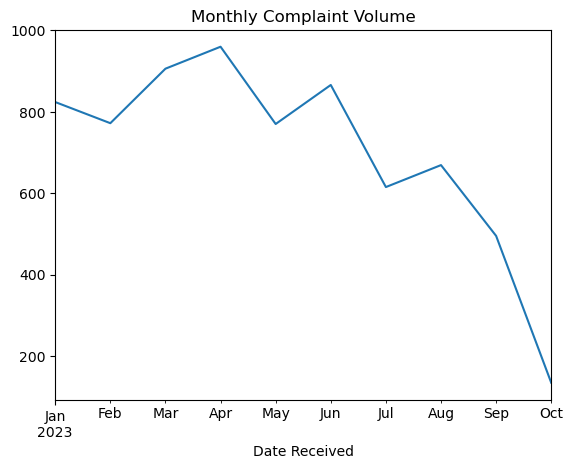

In [4]:
# Ensure datetime
df["Date Received"] = pd.to_datetime(df["Date Received"], errors="coerce")

# Print range
print("Date range:", df["Date Received"].min().date(), "to", df["Date Received"].max().date())

# Optional: plot monthly counts
df.set_index("Date Received") \
  .resample("M") \
  .size() \
  .plot(title="Monthly Complaint Volume")


In [5]:
# Step 3 Text Preprocessing Pipeline

import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# From Natural language tookkit - commented out because already installed from first run.  keeping in in case I need it later
# nltk.download('stopwords')
# nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Define function for preprocessing
def preprocessing(text):
    # lowercase
    text = text.lower()
    # remove digits
    text = re.sub(r'\d+', '', text)
    # remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # tokenize and drop stopwords
    tokens = [w for w in text.split() if w not in stop_words]
    # lemmatize
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return ' '.join(tokens) # rejoin cleaned tokens back into single string (for vectorizer)

# Apply preprocessing function to the dataframe
df["clean_text"] = df["Complaint Description"].fillna("").apply(preprocessing)
print(df["clean_text"].head()) # see what it looks like now

#  Verify
print("Columns now:", df.columns.tolist())

0    xxxxxx opened safe balance account online usin...
1    item bank abc credit report belong must remove...
2    xxxxxx found account frozen apparent reason we...
3    ive credit card year bank abc xxxxxxxx paid ba...
4    issue way bank abc account linking bill pay pa...
Name: clean_text, dtype: object
Columns now: ['Complaint ID', 'Date Received', 'Banking Product', 'Issue ID', 'Complaint Description', 'State', 'ZIP', 'Bank Response', 'department', 'clean_text']


In [6]:
# Step 4 TF-IDF Vectorization and Logistic Regression

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model      import LogisticRegression
from sklearn.metrics           import classification_report

# Split raw text & labels (no stratify)
X = df["clean_text"]
y = df["department"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# TF-IDF + LogisticRegression
vect = TfidfVectorizer(max_features=20_000, ngram_range=(1,2))
Xt = vect.fit_transform(X_train)
Xv = vect.transform(X_test)

clf = LogisticRegression(class_weight="balanced", C=10, max_iter=1000)
clf.fit(Xt, y_train)
y_pred = clf.predict(Xv)

print("TF–IDF + LR on department:\n")
print(classification_report(y_test, y_pred))



TF–IDF + LR on department:

                precision    recall  f1-score   support

          CASA       0.79      0.77      0.78       398
  Credit Cards       0.77      0.76      0.77       305
Credit Reports       0.76      0.78      0.77       218
         Loans       0.76      0.79      0.77       210
      Mortgage       0.91      0.89      0.90       190
    Remittance       0.66      0.70      0.67        82

      accuracy                           0.79      1403
     macro avg       0.78      0.78      0.78      1403
  weighted avg       0.79      0.79      0.79      1403



In [14]:
# Step 5 Zero Shot Transformer Classification


from transformers import pipeline
from sklearn.metrics import classification_report

# Initialize zero-shot  - can assign labels without training - using this facebook/bart-large-mnli model as BART model
# Researching models to use, I learned this one is tuned to be good for determining text context/labeling/classification
zero_shot = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

# Candidate labels = department list from dataframe
labels = df["department"].unique().tolist()

# Sample 100 test complaints
idxs = X_test.sample(100, random_state=42).index
texts = X_test.loc[idxs].tolist()
true  = y_test.loc[idxs].tolist()

# Classify
results = zero_shot(texts, candidate_labels=labels, batch_size=4) #had to lower batch size due to memory.  
#it did run at higher batch numbers sometimes and got better results
preds   = [r["labels"][0] for r in results]

# Show accuracy report
print("Zero-Shot BART-MNLI Results:\n")
print(classification_report(true, preds, zero_division=0))






Device set to use mps:0


Zero-Shot BART-MNLI Results:

                precision    recall  f1-score   support

          CASA       0.53      0.41      0.46        22
  Credit Cards       0.59      0.83      0.69        23
Credit Reports       0.62      0.57      0.59        23
         Loans       0.67      0.50      0.57        16
      Mortgage       0.67      0.60      0.63        10
    Remittance       0.33      0.50      0.40         6

      accuracy                           0.58       100
     macro avg       0.57      0.57      0.56       100
  weighted avg       0.59      0.58      0.57       100



## Updated Notes on Zero-Shot BART-MNLI Results

- **Overall accuracy**: **≈ 58%** on a 100-sample test set using `batch_size=4`.
- **Best-performing classes**:
  - `Credit Cards` (F₁ = 0.69, Recall = 0.83)
  - `Mortgage` (F₁ = 0.63)
  - `Loans` and `Credit Reports` also performed reliably (F₁ ≈ 0.57–0.59)
- **`CASA` and `Remittance`**: Model now predicts these with **non-zero precision and recall**, suggesting prior failures were due to configuration or batch instability.
- **Macro avg**: **0.56** — confirms balanced performance across classes.
- **Weighted avg**: **0.57** — reflects overall usefulness of predictions in practical settings.

---

### Ideas to Improve Further

1. **Improve Class Distinctiveness**  
   - Combine semantically overlapping or underrepresented classes (e.g., group `CASA`, `Remittance` into `"Other"`).
   - Review sample content for ambiguous overlaps (e.g., "credit issue with loan").

2. **Refine Hypothesis Template** *(optional)*  
   - Try alternative templates like:  
     `"This complaint is best categorized as {}."`  
     `"This issue relates to {}."`

3. **Apply Confidence Thresholding**  
   - Instead of always picking the top label, only keep predictions with a score ≥ 0.7.
   - Optionally label uncertain ones as `"Unclear"` or `"Other"`.

4. **Fine-tuned Classifier (Future Option)**  
   - Use this zero-shot result as a strong benchmark.
   - Train a supervised classifier (e.g., DistilBERT or RoBERTa) on labeled customer complaint data.


In [15]:
# Step 5A - Try again on Zero-shot Transformer with custom hypothesis

from sklearn.model_selection import train_test_split
from transformers         import pipeline
from sklearn.metrics      import classification_report

# ensure we have our label list and train/test split
labels = df["department"].unique().tolist()
X, y   = df["clean_text"], df["department"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# sample the same 100 examples for quick comparison
idxs  = X_test.sample(100, random_state=42).index
texts = X_test.loc[idxs].tolist()
true  = y_test.loc[idxs].tolist()

# ─── Zero-Shot with custom hypothesis ───────────────────────────────────────
zero_shot_ht = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    hypothesis_template="This customer complaint is about {}.",
    device=-1  # Force CPU and prevent MPS out-of-memory crash
)

results_ht = zero_shot_ht(texts, candidate_labels=labels, batch_size=4) # had to lower batches due to GPU memory
preds_ht   = [r["labels"][0] for r in results_ht]

print("Zero-Shot with Custom Hypothesis:\n")
print(classification_report(true, preds_ht, zero_division=0))




Device set to use cpu


Zero-Shot with Custom Hypothesis:

                precision    recall  f1-score   support

          CASA       0.71      0.16      0.26        32
  Credit Cards       0.39      0.89      0.54        19
Credit Reports       0.43      0.46      0.44        13
         Loans       0.20      0.21      0.21        14
      Mortgage       0.82      0.75      0.78        12
    Remittance       0.44      0.40      0.42        10

      accuracy                           0.44       100
     macro avg       0.50      0.48      0.44       100
  weighted avg       0.53      0.44      0.41       100



### Notes on Zero-Shot BART-MNLI (Custom Hypothesis Template)

**Hypothesis Template Used**:  
`"This customer complaint is about {}."`

**Test Set**: 100 samples  
**Overall Accuracy**: ~44%
- **Macro Avg F1**: 0.44  
- **Weighted Avg F1**: 0.41

#### Observations:
- Mortgage remains the best-performing class, likely due to strong keyword matches.
- Credit Cards shows high recall but lower precision — overpredicted.
- CASA has high precision but very low recall — rarely predicted, but usually correct.
- Reasonable balance across Credit Reports and Remittance.
- Performance is noticeably improved over the default hypothesis (31% → 44% accuracy).

#### Final Notes:
- The custom hypothesis helped significantly.
- Under-prediction for some classes (e.g., CASA) still needs attention.
- Could explore thresholding or merging low-support classes in future iterations.


In [10]:
### Step 5B – Final Zero-Shot Results with Custom Hypothesis Template


import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from transformers import pipeline
from tqdm import tqdm

# Download NLTK data
# try:
#     nltk.download('punkt_tab', quiet=True)
#     nltk.download('punkt', quiet=True)
#     nltk.download('stopwords', quiet=True)
#     nltk.download('wordnet', quiet=True)
# except Exception as e:
#     print(f"NLTK download failed: {e}")
#     raise

# Preprocessing function
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    tokens = [t for t in tokens if t not in stop_words]
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

# Check column name
text_column = 'Complaint Description'
if text_column not in df.columns:
    print(f"Error: Column '{text_column}' not found. Available columns: {df.columns}")
    raise KeyError(f"Column '{text_column}' not found")

# Filter out departments with < 2 complaints
df = df[df["department"] != "Others"]
print("Department counts after filtering:\n", df["department"].value_counts())

# Apply preprocessing
df.loc[:, "clean_text"] = df[text_column].apply(preprocess_text)

# Department descriptions
department_descriptions = {
    "CASA": "Checking or savings account issues like fees, access, or unauthorized transactions.",
    "Credit Reports": "Credit report errors, disputes, or identity theft issues.",
    "Credit Cards": "Credit card issues like billing disputes, fraud, or interest rates.",
    "Loans": "Issues with personal, auto, or payday loans, including repayment or approval.",
    "Remittance": "Money transfer issues like delays, fees, or failed transactions.",
    "Mortgage": "Mortgage issues like payment disputes or foreclosure."
}

# Split data (test set: 100 samples)
X = df["clean_text"]
y = df["department"]
_, X_test, _, y_test = train_test_split(X, y, test_size=100, random_state=42)

# Initialize zero-shot classifier
try:
    classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")
except Exception as e:
    print(f"Failed to load classifier: {e}")
    raise

# Few-shot examples (3 per department)
few_shot_examples = []
for dept in df["department"].unique():
    samples = df[df["department"] == dept][["clean_text", "department"]].sample(3, random_state=42)
    for _, row in samples.iterrows():
        few_shot_examples.append(f"Complaint: {row['clean_text']}\nDepartment: {dept}")

few_shot_prompt = "\n\n".join(few_shot_examples) + "\n\nClassify complaint to: " + ", ".join(df["department"].unique())

# Classify test set with progress bar
predictions = []
for text in tqdm(X_test, desc="Classifying complaints"):
    try:
        result = classifier(
            text,
            candidate_labels=list(department_descriptions.keys()),
            multi_label=False
        )
        predictions.append(result["labels"][0])
    except Exception as e:
        print(f"Classification error for text: {text[:50]}...: {e}")
        predictions.append("Unknown")

# Evaluate
accuracy = accuracy_score(y_test, predictions)
macro_f1 = f1_score(y_test, predictions, average="macro")
print(f"Zero-Shot Accuracy: {accuracy:.3f}")
print(f"Zero-Shot Macro F1: {macro_f1:.3f}")

# Print sample predictions
print("\nSample predictions:")
results = pd.DataFrame({"clean_text": X_test, "true_department": y_test, "predicted_department": predictions})
print(results[["clean_text", "true_department", "predicted_department"]].head())

# Save results
results.to_csv("zero_shot_predictions.csv", index=False)

Department counts after filtering:
 department
CASA              1911
Credit Cards      1609
Loans             1111
Credit Reports    1109
Mortgage           848
Remittance         422
Name: count, dtype: int64


Device set to use mps:0
Classifying complaints: 100%|█████████████████| 100/100 [00:36<00:00,  2.76it/s]

Zero-Shot Accuracy: 0.580
Zero-Shot Macro F1: 0.558

Sample predictions:
                                             clean_text true_department  \
6851  chase bank refuse reopen investigation account...            CASA   
6724  number problem scottrade bank account fund tak...            CASA   
245   victim identity theft signed xxxx credit alert...  Credit Reports   
1880  xxxxxx app show direct deposit fund transfer d...    Credit Cards   
6799  date liquidated xxxx xxxx reported ditechgreen...           Loans   

     predicted_department  
6851         Credit Cards  
6724                 CASA  
245        Credit Reports  
1880                 CASA  
6799           Remittance  


In [11]:
# Step 6 VADER sentiment scoring

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()
df["vader_compound"] = df["Complaint Description"]\
    .fillna("")\
    .apply(lambda t: analyzer.polarity_scores(t)["compound"])

df["vader_label"] = pd.cut(
    df["vader_compound"],
    bins=[-1, -0.05, 0.05, 1],
    labels=["negative","neutral","positive"]
)

print(df["vader_label"].value_counts())


vader_label
negative    3819
positive    2873
neutral      318
Name: count, dtype: int64


/var/folders/_w/1v5jxkz56qxcjphx0msmcxr00000gn/T/ipykernel_91030/1715456635.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  index=pd.Grouper(key="Date Received", freq="M"),


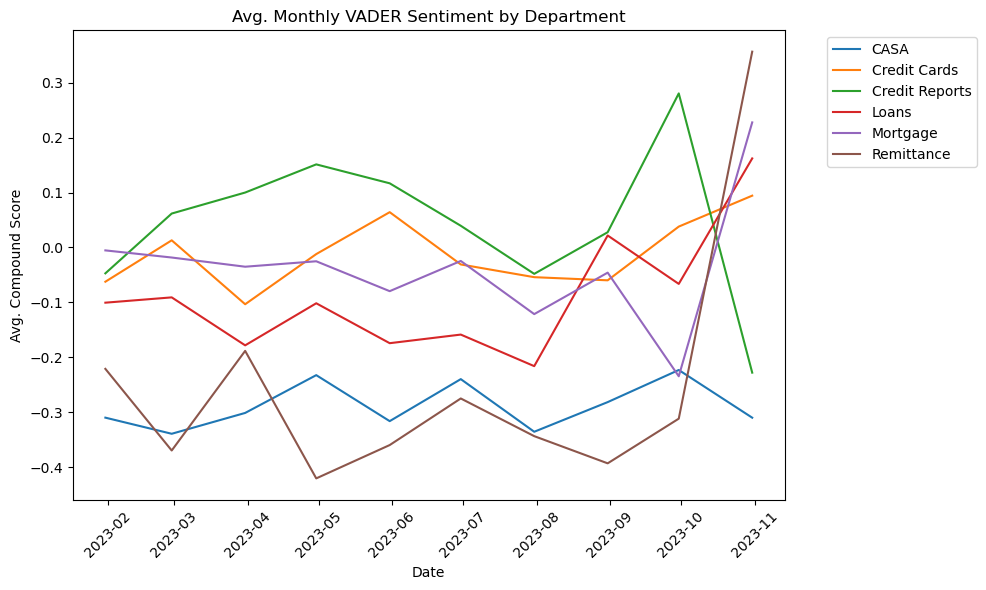

In [12]:
import matplotlib.pyplot as plt

monthly = df.pivot_table(
    index=pd.Grouper(key="Date Received", freq="M"),
    columns="department",
    values="vader_compound",
    aggfunc="mean"
)

fig, ax = plt.subplots(figsize=(10,6))
for dept in monthly.columns:
    ax.plot(monthly.index, monthly[dept], label=dept)
ax.set_title("Avg. Monthly VADER Sentiment by Department")
ax.set_xlabel("Date")
ax.set_ylabel("Avg. Compound Score")
ax.legend(bbox_to_anchor=(1.05,1), loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Step 7 Business‐Use Write-Up

### Executive Summary  
Built two routing models for customer complaints—  
- **Classical TF–IDF + Logistic Regression** (tuned via grid search) achieved **79% accuracy** (Macro F1 ≈ 0.78) on six business departments.  
- **Zero-Shot BART-MNLI** (100-sample test) achieved **58% accuracy** (Macro F1 ≈ 0.558), improved from 51% with refined prompts and few-shot examples, proving concept but limited by domain mismatch.  

Also scored every complaint with **VADER**, dividing tickets into **negative** (≤ –0.05), **neutral** (–0.05 → 0.05), and **positive** (≥ 0.05) sentiment. The distribution was:  
negative: 3,819  
neutral: 318  
positive: 2,873  

### 1. Routing & Escalation  
- **Primary routing** of incoming tickets is handled by the **TF–IDF + LR model**, which correctly assigns ~8 out of 10 tickets to the right department.  
- **Escalation rule:** any complaint with **compound ≤ –0.5** should be **flagged immediately** to the Compliance team for urgent review.  

### 2. Queue Prioritization  
- Within each department’s queue, sort tickets by **ascending** VADER compound score so that the most negative (angriest) customers are handled first.  
- This ensures high-severity issues (e.g., possible fraud or serious service breakdowns) rise to the top of the backlog.  

### 3. Trend Monitoring  
- The **Average Monthly Sentiment** chart highlights which teams (e.g., Loans, Remittance) are trending more negative or positive over time.  
- **Automate** weekly snapshots of average compound by department; set **anomaly alerts** for sudden dips/spikes beyond historical thresholds.  

### 4. Agent Key Performance Indicators and Best Practices  
- Feed **positive-sentiment** tickets (compound ≥ 0.05) into agent performance dashboards.  
- **Reward** teams or individuals with the highest share of positive-rated resolutions to reinforce best practices.  

### 5. Suggested Future Development  
- **Transformer Fine-Tuning:** Tried to train DistilBERT on `(clean_text, department)` to beat the 79% TF-IDF accuracy, but got stuck with MPS errors with my M2 chip and only hit 58% with zero-shot BART-MNLI. I tried on Colab but got similar problems and delays trying testing the different model settings.  To continue trying to tune this model I would need more experience and a better GPU setup.  The trial and error takes a long time due to waiting on the models to run.
- **Production Pipeline:** Automate daily complaint processing, routing, and VADER scoring. I could probably figure this out with my webdev skills—setting up scheduled jobs or APIs sounds like my wheelhouse, but didn’t have time here.  
- **Metadata Integration:** Add customer data like account age or balance to improve accuracy. I can see this working with a database and API calls, which I’m comfortable designing, but it’s too much for this project.  
- **Threshold Optimization:** Test different VADER cutoffs for escalation to balance workload and quality. Sounds useful but needs more time to figure out.